Completed Tasks 1–9, run on the official ButterflAI 2.0 catalog at commit `0129aea104aec57f5534f9b8472db66f98e54bc7`.

Tasks 1–2 use peak-area observations and the frozen 1.0 latitude model. Tasks 3–9 use first observations. Cycles 12–23 and lifetime peak area >30 MSH are used. All 17 window widths were computed. The classroom's 20 simulation realizations were increased to 1,000. Results are descriptive Week 1 scores, not held-out validation.

To rerun, place this notebook inside a clone of the ButterflAI 2.0 repository and run its standard setup cell. The catalog and frozen legacy model must be present.


# 🦋 Week 1 — The butterfly as a counting process

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai2/blob/main/weeks/week_01/01_counting_process.ipynb)

> Is sunspot emergence consistent with a memoryless (Poisson) process, and at what timescales?

A sunspot group appears when a bundle of magnetic field rises through the photosphere and breaks the
surface — its **emergence**. That is the single event this whole program is about.

ButterflAI 1.0 answered *where* emergence happens: given that a group emerged at time `s`, it predicted
the distribution of its latitude. It never answered *how many* emerge, so it could not generate a solar
cycle on its own.

This program builds the missing half. The object we are after is an emission intensity Λ(λ, s) whose
integral over latitude is the emergence rate — how many groups per year, at what latitudes. Before we can
fit such a thing, we have to decide what kind of random process we are fitting it to. That is this week.

The data is a catalog of sunspot groups. Each group appeared once, somewhere, at some time. A dataset of
that shape — a list of *when and where something happened*, rather than a value measured on a grid — is a
**point process**. Its realization is a set of event times, not a vector; it has no value "at" a time
where nothing happened, and the number of events is itself random. Almost every intuition carried over
from fitting curves to measurements needs re-examining.

What you will produce by the end:

1. An *emergence table* — one event per sunspot group, at the moment it was first seen.
2. N(s), the running count of emergences in each hemispheric cycle.
3. F(Δ), the Fano factor as a function of window width, for the data and for a Poisson comparison.
4. An argument about what F(Δ) does and does not tell you.

Sections 1 is given code with no tasks — it is ButterflAI 1.0 compressed into a few cells. If you are
returning from 1.0, skim it. If you are new, run it and read it: everything after it uses its vocabulary.

Tasks 1–9 are yours.


---
## How to work this notebook

Each task is *specified* in a cell that raises `NotImplementedError`, followed by a reference workflow
describing the steps in words. Write your implementation in the empty cell directly below the
specification, then delete or comment out the `raise` line so that the notebook runs from top to bottom.
Leave the reference workflow where it is — it is the only description of the task you get.

Before you implement anything, open a session with the tutor prompt in `vocal_prompt_week01.md`: paste
that file, then this whole notebook, then your first question. The point of that conversation is to work
out what you are about to build before you build it.

Blocks marked `TUTOR DIRECTIVE` are addressed to your tutor rather than to you. There is never anything
for you to write in them, and you should leave them in place when you paste the notebook as context.


```text
TUTOR DIRECTIVE — session opening.

The student has pasted this entire notebook as context. Nothing in it has been run: every task raises
NotImplementedError, each is followed by a reference workflow, and the empty cell beneath each task is
the student's own workspace, not an omission for you to fill in. This session happens before they
implement anything, and its purpose is the conversation they have about what they are going to build.

So: do not write their task code, and do not walk them through a reference workflow step by step. Two
further TUTOR DIRECTIVE blocks appear later, at Sections 2 and 6, and each names the destinations the
conversation has to reach at that point. Everything else in the notebook is material you may draw on.

This week's targets are the terms set in bold in the notebook text, each bolded where it is first
introduced. The student has therefore read a definition of every one of them, and has almost certainly
used none of them in a sentence of their own. Treat them all as unused: having read a term here does
not put it on the table, and you still have to introduce it yourself before asking them to deploy it.
```

In [ ]:
# ── ButterflAI 2.0 standard setup — run this first ─────────────────────────
import os, sys, random, subprocess
from pathlib import Path

REPO_URL = "https://github.com/SwRI-IDEA-Lab/butterflai2.git"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO = Path("/content/butterflai2")
    if REPO.exists():
        subprocess.run(["git", "-C", str(REPO), "pull", "--ff-only"], check=False)
    else:
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                    str(REPO / "requirements.txt")], check=True)
else:
    # Local: walk up from the notebook's folder to the repository root.
    REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / "legacy" / "butterflAI_model.py").exists()), None)
    if REPO is None:
        raise RuntimeError("Could not find the butterflai2 repository root. "
                           "Open this notebook from inside your clone.")

DATA = REPO / "data"
DERIVED = DATA / "derived"
DERIVED.mkdir(exist_ok=True)
LEGACY = REPO / "legacy"
sys.path.insert(0, str(LEGACY))   # enables: from butterflAI_model import ButterflAIModel

SEED = 42
random.seed(SEED)
import numpy as np
np.random.seed(SEED)
try:
    import torch
    torch.manual_seed(SEED)
    DEVICE = torch.device("cuda" if torch.cuda.is_available()
                          else "mps" if torch.backends.mps.is_available() else "cpu")
except ImportError:
    DEVICE = "cpu"

print(f"🦋 ButterflAI 2.0 | {'Colab' if IN_COLAB else 'local'} | repo: {REPO} | device: {DEVICE}")

In [5]:
# Everything else this notebook needs. Phase A is numpy and scipy only; PyTorch arrives in Week 5.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance

from butterflAI_model import ButterflAIModel, A_REF

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.titlesize": 11, "figure.titlesize": 12})

# ── Constants used throughout. Each one is a decision; none is a magic number. ──
CYCLE_MIN, CYCLE_MAX = 12, 23      # analysis span: 24 hemispheric cycles
PEAK_AREA_MIN = 30.0               # MSH — drops pores and the smallest groups
AMP_AREA_MIN = 50.0                # MSH — ButterflAI 1.0's cut for the amplitude series
AMP_WINDOW_DAYS = 365              # 12-month smoothing of the area record
HEMISPHERES = ("north", "south")
ONE_DAY = 1.0 / 365.25             # one day, in years — our time unit everywhere

print(f"analysis span: cycles {CYCLE_MIN}-{CYCLE_MAX}, both hemispheres "
      f"= {2 * (CYCLE_MAX - CYCLE_MIN + 1)} hemispheric cycles")

analysis span: cycles 12-23, both hemispheres = 24 hemispheric cycles


---
## 1 · ButterflAI 1.0, as runnable code

*Given code — no tasks. Skim if you are returning from 1.0.*

### 1.1 · What the catalog contains

One row is one sunspot group, observed on one day: its time, heliographic latitude and longitude, and its
foreshortening-corrected area in millionths of a solar hemisphere (MSH). A group that lived for two weeks
contributes a dozen or so rows, all sharing one `uniqueID`. Rows without a `uniqueID` are days on which no
spots were recorded.

So the catalog is not yet a point process. It is a set of *measurements of groups*, and a group is not an
event — it is an object with a lifetime. Turning one into the other is a modeling choice, and it is the
first thing we have to make explicit.

In [7]:
CATALOG = DATA / "composite_sunspot_groups_daily_measurements_10_23.csv"
daily = pd.read_csv(CATALOG)


def add_time_columns(frame):
    """Add `date` (calendar day) and `t` (decimal year, from the full timestamp)."""
    stamp = pd.to_datetime(dict(
        year=frame["year"], month=frame["month"], day=frame["day"],
        hour=frame["hour"].fillna(12).astype(int),
        minute=frame["minute"].fillna(0).astype(int),
        second=frame["second"].fillna(0).astype(int),
    ))
    day_of_year = (stamp.dt.dayofyear - 1 + stamp.dt.hour / 24.0
                   + stamp.dt.minute / 1440.0 + stamp.dt.second / 86400.0)
    year_length = np.where(stamp.dt.is_leap_year, 366.0, 365.0)
    frame = frame.copy()
    frame["date"] = stamp.dt.normalize()
    frame["t"] = stamp.dt.year + day_of_year / year_length
    return frame


daily = add_time_columns(daily)
obs = daily[daily["uniqueID"].notna()].copy()      # the actual group observations

print(f"catalog rows              : {len(daily):,}")
print(f"rows with a group id      : {len(obs):,}")
print(f"distinct sunspot groups   : {obs['uniqueID'].nunique():,}")
print(f"observations per group    : median {obs.groupby('uniqueID').size().median():.0f}, "
      f"max {obs.groupby('uniqueID').size().max()}")
print(f"time span                 : {obs['t'].min():.1f} to {obs['t'].max():.1f}")

assert obs["uniqueID"].nunique() == 46_110, "the catalog should hold 46,110 distinct groups"

catalog rows              : 314,648
rows with a group id      : 249,752
distinct sunspot groups   : 46,110
observations per group    : median 4, max 28
time span                 : 1825.8 to 2023.8


### 1.2 · 1.0's event convention: the group at its largest

ButterflAI 1.0 represented each group by its *maximum-area* observation — the day the group was biggest —
and used the latitude measured on that day. Peak area is a good estimate of where a group is: the group is
large, well resolved, and usually near disk center. The resulting scatter plot of latitude against time is
the butterfly diagram.

We reproduce that table here because 1.0's fitted model is expressed in terms of it, and because the cycle
amplitudes in Section 1.4 are built from it. In Section 3 we will deliberately *change* the event
convention, and the reason will matter.

In [9]:
peak_rows = obs.loc[obs.groupby("uniqueID")["correctedArea"].idxmax()]
peak_rows = peak_rows[peak_rows["latitude"].notna() & peak_rows["CYCLE"].notna()]

groups10 = pd.DataFrame({
    "uniqueID": peak_rows["uniqueID"].to_numpy(),
    "date": peak_rows["date"].to_numpy(),
    "t": peak_rows["t"].to_numpy(),
    "latitude": peak_rows["latitude"].to_numpy(),
    "peak_area": peak_rows["correctedArea"].to_numpy(),
    "cycle": peak_rows["CYCLE"].astype(int).to_numpy(),
})
groups10["abs_latitude"] = groups10["latitude"].abs()
groups10["hemisphere"] = np.where(groups10["latitude"] >= 0, "north", "south")

# 1.0 removed pores and the smallest objects before fitting anything.
shape_table = groups10[groups10["peak_area"] > PEAK_AREA_MIN].copy()

print(f"groups with a cycle label and a latitude : {len(groups10):,}")
print(f"after the > {PEAK_AREA_MIN:.0f} MSH cut            : {len(shape_table):,}")

groups with a cycle label and a latitude : 45,612
after the > 30 MSH cut            : 32,080


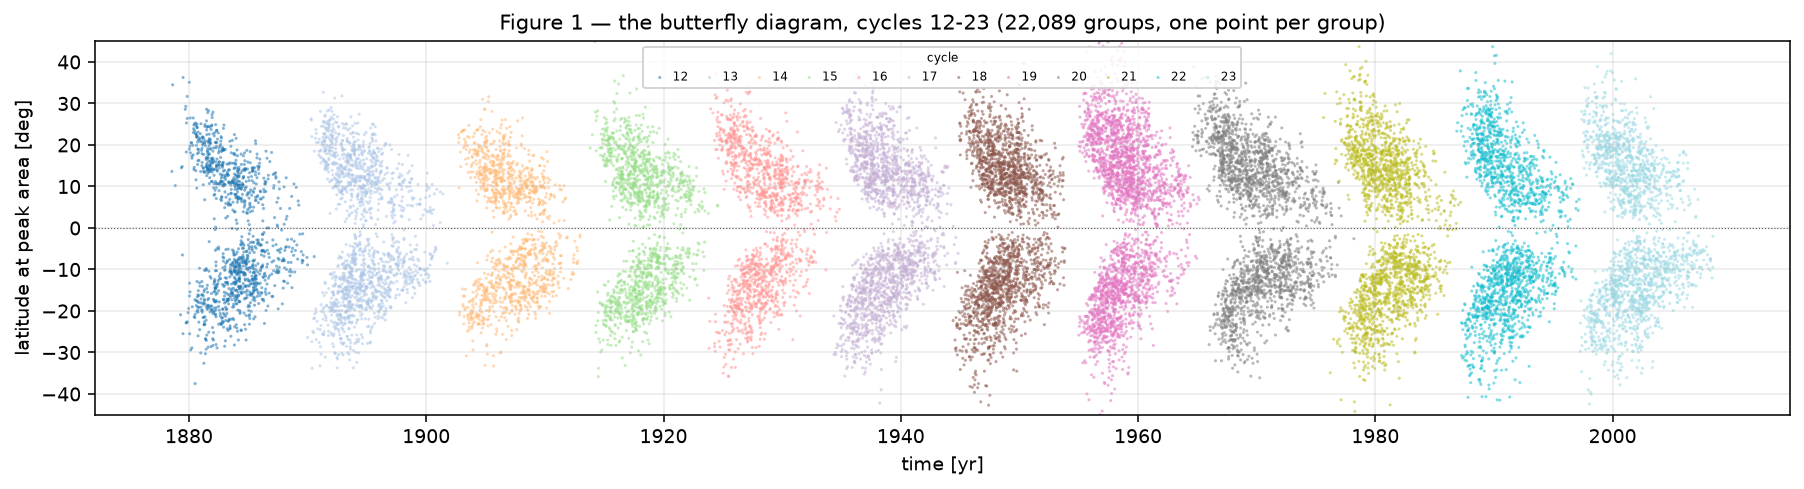

In [12]:
fig, ax = plt.subplots(figsize=(13, 3.6))
span = shape_table[shape_table["cycle"].between(CYCLE_MIN, CYCLE_MAX)]
colors = plt.get_cmap("tab20", CYCLE_MAX - CYCLE_MIN + 1)
for i, cyc in enumerate(range(CYCLE_MIN, CYCLE_MAX + 1)):
    sel = span[span["cycle"] == cyc]
    ax.scatter(sel["t"], sel["latitude"], s=2.5, color=colors(i), alpha=0.55,
               edgecolors="none", label=f"{cyc}")
ax.axhline(0.0, color="k", lw=0.6, ls=":", alpha=0.6)
ax.set_xlabel("time [yr]")
ax.set_ylabel("latitude at peak area [deg]")
ax.set_ylim(-45, 45)
ax.set_title(f"Figure 1 — the butterfly diagram, cycles {CYCLE_MIN}-{CYCLE_MAX} "
             f"({len(span):,} groups, one point per group)")
ax.legend(ncol=12, fontsize=6, loc="upper center", title="cycle", title_fontsize=6,
          columnspacing=0.8, handletextpad=0.1, framealpha=0.85)
plt.tight_layout()
plt.show()

Each wing starts near 30° and drifts toward the equator. The wings of consecutive cycles overlap in time:
while one cycle is finishing near the equator, the next is already starting at high latitude. So calendar
time is the wrong x-axis for modeling a single wing — we need a clock that starts fresh for each wing.

### 1.3 · The alignment coordinate `s`

The unit of replication in this program is the **hemispheric cycle**: the north and the south of one solar
cycle are two separate wings, with their own timing, and we treat them as independent units. Cycles
12 through 23 give us 24 of them.

Each wing gets its own clock. The **alignment coordinate** `s` is the time in years since that wing's mean
latitude crossed 15° on its way to the equator:

```
s = t − t0(cycle, hemisphere)
```

Three things about `s` that matter for the rest of the program:

- It is a *shift*, not a rescaling. Each wing's clock is moved, never stretched. A wing that lasts 12 years
  still lasts 12 years in `s`. We never express time as a fraction of cycle length, and never as a named
  stage of the cycle — those collapse exactly the duration differences we want the model to explain.
- `s` runs negative. The wing starts at high latitude some 3 to 5 years *before* it reaches 15°.
- `t0` is derived from the data, which means it is a fitted quantity and can leak information between
  training and test sets. This week we take `t0` from 1.0's fit, as given. From Week 3 onward, every
  validation fold re-derives it from that fold's training data only.

ButterflAI 1.0 calls this same quantity `tau`. The letter changed in 2.0 because `tau` is too easily read
as a normalized phase running 0 to 1, which this is not. The frozen code in `legacy/` keeps its original
argument names, so calls into it still say `tau=`.

In [12]:
model = ButterflAIModel()
print(model)

CYCLES = list(range(CYCLE_MIN, CYCLE_MAX + 1))
T0 = {(c, h): model.lookup_t0(c, h) for c in CYCLES for h in HEMISPHERES}

shape_span = shape_table[shape_table["cycle"].between(CYCLE_MIN, CYCLE_MAX)].copy()
shape_span["t0"] = [T0[(c, h)] for c, h in zip(shape_span["cycle"], shape_span["hemisphere"])]
shape_span["s"] = shape_span["t"] - shape_span["t0"]

print(f"\n15-degree crossing epochs t0 (first four):")
for key in list(T0)[:4]:
    print(f"   cycle {key[0]} {key[1]:<5s}  t0 = {T0[key]:9.2f}")
print(f"\ns ranges from {shape_span['s'].min():+.2f} to {shape_span['s'].max():+.2f} yr; "
      f"{(shape_span['s'] < 0).mean() * 100:.0f}% of groups have s < 0")

<ButterflAIModel  N_hemicycles=26  NLL=3.0708  coverage=0.963>

15-degree crossing epochs t0 (first four):
   cycle 12 north  t0 =   1882.60
   cycle 12 south  t0 =   1882.15
   cycle 13 north  t0 =   1892.90
   cycle 13 south  t0 =   1893.62

s ranges from -4.78 to +8.75 yr; 40% of groups have s < 0


### 1.4 · The amplitude of a hemispheric cycle

1.0's latitude distribution is conditioned on one number per wing: the cycle's amplitude `A`. Strong cycles
emerge at higher latitudes and spread wider than weak ones, and `A` is what carries that.

`A` is the peak of the 12-month-smoothed total sunspot area of that hemisphere, and it is measured from the
groups-at-peak-area table — one contribution per group, not one per daily observation. Getting that detail
wrong inflates `A` by a factor of about five, because the average group is observed on five days.

The units are a genuine trap. 1.0's amplitude regressions were fit on area divided by
`A_REF` = 1000, so real hemispheric cycles run `A` ≈ 0.08 to 0.32. Passing raw MSH is numerically
harmless and physically ruinous: it pushes the cap latitude μ₀(A) up past anything the mean path ever
reaches, which silently switches off the gate that ends a wing. The frozen code now raises rather than
degrade quietly, but the lesson generalizes — a parameter with units is not a number.

In [14]:
amp_source = shape_table[(shape_table["cycle"] >= CYCLE_MIN)
                         & (shape_table["peak_area"] > AMP_AREA_MIN)]

# One contiguous daily grid, zero-filled, so the rolling window is honest about quiet days.
grid = pd.date_range(amp_source["date"].min(), amp_source["date"].max(), freq="D")
smoothed_area = {}
for hemi in HEMISPHERES:
    per_day = (amp_source[amp_source["hemisphere"] == hemi]
               .groupby("date")["peak_area"].sum()
               .reindex(grid, fill_value=0.0))
    smoothed_area[hemi] = per_day.rolling(AMP_WINDOW_DAYS, center=True,
                                          min_periods=AMP_WINDOW_DAYS // 3).mean()

AMPLITUDE = {}
amp_rows = []
for cyc in CYCLES:
    cycle_dates = shape_table.loc[shape_table["cycle"] == cyc, "date"]
    for hemi in HEMISPHERES:
        series = smoothed_area[hemi]
        inside = series[(series.index >= cycle_dates.min())
                        & (series.index <= cycle_dates.max())].dropna()
        peak_msh = float(inside.max())
        AMPLITUDE[(cyc, hemi)] = peak_msh / A_REF
        amp_rows.append(dict(cycle=cyc, hemisphere=hemi, peak_msh=peak_msh,
                             A=peak_msh / A_REF, peak_date=inside.idxmax().date(),
                             mu_0=float(model.mu_0(peak_msh / A_REF))))

amp_table = pd.DataFrame(amp_rows)
print(amp_table.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))
print(f"\nA spans {amp_table['A'].min():.3f} to {amp_table['A'].max():.3f} "
      f"(legacy/ documents 0.08-0.32 for real hemispheric cycles)")
strongest = amp_table.loc[amp_table["A"].idxmax()]
weakest = amp_table.loc[amp_table["A"].idxmin()]
print(f"strongest: cycle {strongest['cycle']} {strongest['hemisphere']} (A = {strongest['A']:.3f})")
print(f"weakest  : cycle {weakest['cycle']} {weakest['hemisphere']} (A = {weakest['A']:.3f})")

assert 0.07 < amp_table["A"].min() and amp_table["A"].max() < 0.35, \
    "amplitudes are outside the range 1.0's regressions were fit on — check the MSH/1000 conversion"

 cycle hemisphere  peak_msh        A  peak_date     mu_0
    12      north    78.977    0.079 1882-05-20   23.186
    12      south   148.840    0.149 1883-12-01   24.387
    13      north    97.033    0.097 1892-03-01   23.497
    13      south   145.326    0.145 1893-11-20   24.326
    14      north   115.463    0.115 1906-01-19   23.813
    14      south    85.957    0.086 1907-07-15   23.306
    15      north   130.434    0.130 1917-06-30   24.070
    15      south   116.326    0.116 1917-08-15   23.828
    16      north   113.531    0.114 1926-05-25   23.780
    16      south   117.226    0.117 1928-02-08   23.844
    17      north   210.934    0.211 1937-07-23   25.454
    17      south   160.708    0.161 1938-08-06   24.591
    18      north   193.088    0.193 1949-08-19   25.147
    18      south   237.331    0.237 1947-06-10   25.907
    19      north   315.170    0.315 1959-06-23   27.245
    19      south   257.640    0.258 1957-10-02   26.256
    20      north   164.548    

### 1.5 · The 1.0 model, drawn on the data

With `A` and `s` in hand, 1.0 gives a normalized distribution of |latitude| at every instant:

```
p(|λ| | A, s) = Normal(|λ|; μ(s), σ(μ(s), A)),   and zero once μ(s) > μ₀(A)
```

The mean path μ(s) is a single universal exponential decay toward the equator, shared by every wing. The
width σ depends on the mean latitude and on the cycle's amplitude. The cap μ₀(A) is a hard gate: before the
wing's mean latitude has fallen below μ₀, the model says no emergence is possible at all.

Note what this model is and is not. It is a distribution over *latitude given that something emerged*. It
integrates to 1 at every `s`, so it carries no information about how many groups emerge, or when. That
missing normalization is the whole subject of this program.

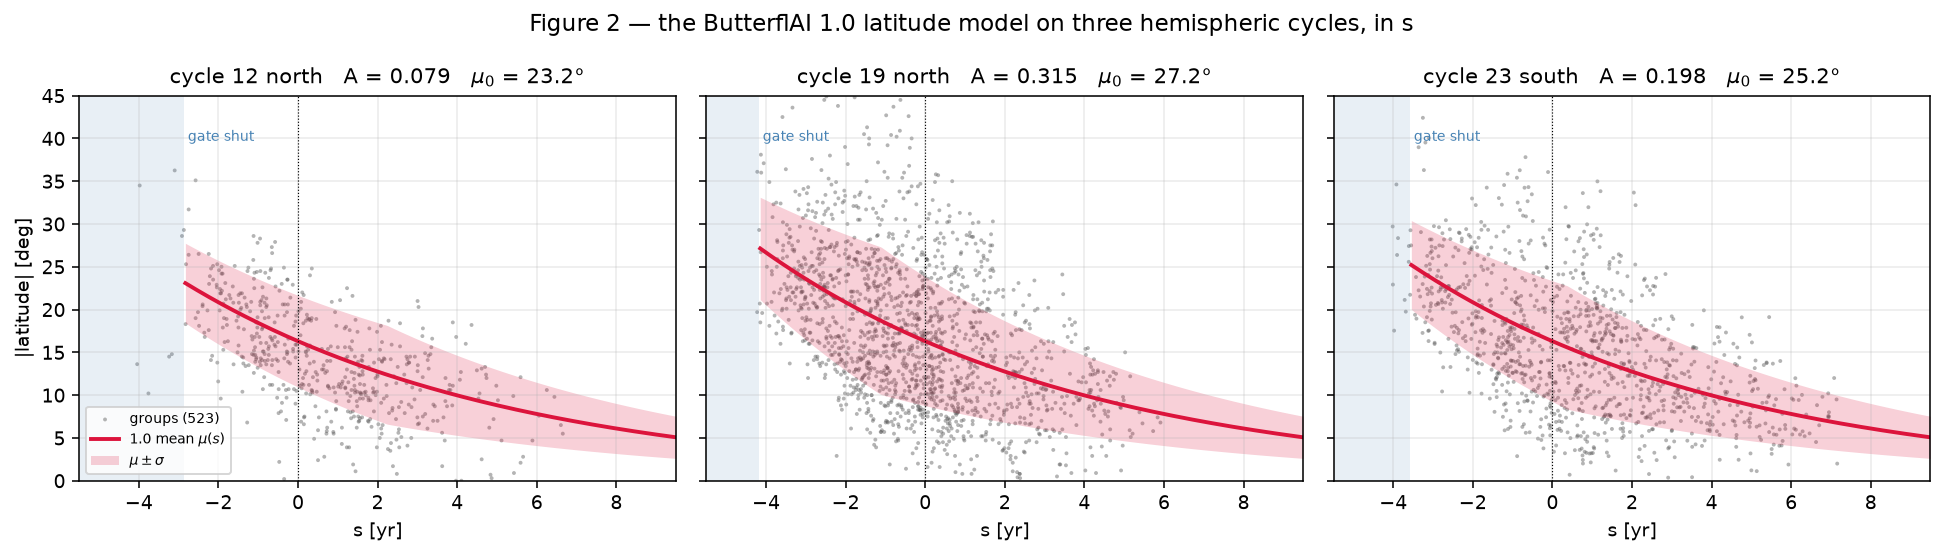

In [16]:
showcase = [(12, "north"), (19, "north"), (23, "south")]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
s_grid = np.linspace(-5.5, 9.5, 400)

for ax, (cyc, hemi) in zip(axes, showcase):
    amp = AMPLITUDE[(cyc, hemi)]
    sel = shape_span[(shape_span["cycle"] == cyc) & (shape_span["hemisphere"] == hemi)]
    mu, sigma = model.gaussian(A=amp, tau=s_grid)
    live = model.is_active(A=amp, tau=s_grid)

    ax.scatter(sel["s"], sel["abs_latitude"], s=4, color="0.35", alpha=0.45, edgecolors="none",
               label=f"groups ({len(sel)})")
    ax.plot(s_grid[live], mu[live], color="crimson", lw=2.0, label=r"1.0 mean $\mu(s)$")
    ax.fill_between(s_grid[live], (mu - sigma)[live], (mu + sigma)[live],
                    color="crimson", alpha=0.20, lw=0, label=r"$\mu \pm \sigma$")
    if (~live).any():
        ax.axvspan(s_grid.min(), s_grid[~live].max(), color="steelblue", alpha=0.12, lw=0)
        ax.text(s_grid[~live].max(), 41, " gate shut ", fontsize=7, color="steelblue",
                ha="left", va="top")
    ax.axvline(0.0, color="k", lw=0.6, ls=":")
    ax.set_xlabel("s [yr]")
    ax.set_title(f"cycle {cyc} {hemi}   A = {amp:.3f}   " + r"$\mu_0$ = " + f"{model.mu_0(amp):.1f}°")
    ax.set_xlim(s_grid.min(), s_grid.max())
    ax.set_ylim(0, 45)

axes[0].set_ylabel("|latitude| [deg]")
axes[0].legend(fontsize=7, loc="lower left")
fig.suptitle("Figure 2 — the ButterflAI 1.0 latitude model on three hemispheric cycles, in s")
plt.tight_layout()
plt.show()

The shaded band on the left of each panel is where the gate is shut: μ(s) is still above the cap μ₀(A), so
the model assigns probability zero there. Notice that real groups are plotted inside it. Hold on to that —
it is about to cost us.

---
## 2 · Two ways to score a model of latitudes

Before changing anything about the model, we need a way to say whether one model is better than another.
There is never one obvious answer, so it pays to hold two metrics at once and watch where they disagree.

### Metric one: negative log-likelihood

The model gives a probability density for each observed latitude. The **negative log-likelihood** of an
event is −log p, and the score for a dataset is the average over events, in *nats per event*. A nat is the
unit of information you get from using natural logarithms; lower is better.

Two properties make it the natural choice, and one makes it dangerous:

- It is the quantity that fitting a probability model maximizes, so scoring with it and fitting with it are
  the same operation. Every model in this program, classical or neural, is trained on a likelihood.
- It is sensitive to the whole shape of the distribution, not just its center or spread.
- It is unbounded. A single event the model called impossible costs infinity, and no amount of good
  prediction elsewhere can pay that back.

That last point is not hypothetical here, as Figure 2 warned.

In [ ]:
# raise NotImplementedError("Task 1: Per-event negative log-likelihood under the 1.0 latitude density")
# Reference workflow:
#   1. For every row of `shape_span`, look up its hemispheric cycle's amplitude in `AMPLITUDE`, and collect
#      its `s` and `abs_latitude` as plain numpy arrays.
#   2. Evaluate the 1.0 density at those three arrays at once — `model.density` broadcasts over all of them.
#      Remember that the frozen code wants the alignment coordinate passed as `tau=`.
#   3. Take minus the natural log. Guard the log of zero so it yields +inf instead of raising; `np.errstate`
#      is the usual way.
#   4. Average over the events the model did not call impossible, and keep the mask of which ones those were.

In [19]:
A_of_event=np.array([AMPLITUDE[(c,h)] for c,h in zip(shape_span.cycle,shape_span.hemisphere)])
s_of_event=shape_span.s.to_numpy()
abs_lat_of_event=shape_span.abs_latitude.to_numpy()
p=model.density(A=A_of_event,tau=s_of_event,abs_lat=abs_lat_of_event)
with np.errstate(divide='ignore'):
    nll_of_event=-np.log(p)
scored=np.isfinite(nll_of_event)
nll_mean=float(nll_of_event[scored].mean())

In [21]:
# Given: what that score is made of.
n_impossible = int((~scored).sum())
print(f"events scored                      : {len(nll_of_event):,}")
print(f"mean NLL over finite events        : {nll_mean:.4f} nats/event")
print(f"events assigned zero density       : {n_impossible} "
      f"({n_impossible / len(nll_of_event) * 100:.2f}%)  -> NLL = +inf")
if n_impossible:
    print(f"   their s range                   : {s_of_event[~scored].min():+.2f} to "
          f"{s_of_event[~scored].max():+.2f} yr")
    print(f"   their |latitude| range          : {abs_lat_of_event[~scored].min():.1f} to "
          f"{abs_lat_of_event[~scored].max():.1f} deg")
print(f"\nstrictly honest total score        : {np.mean(nll_of_event):.4f} nats/event")

events scored                      : 22,089
mean NLL over finite events        : 3.2024 nats/event
events assigned zero density       : 110 (0.50%)  -> NLL = +inf
   their s range                   : -4.78 to -2.87 yr
   their |latitude| range          : 10.2 to 41.4 deg

strictly honest total score        : inf nats/event


The honest total is infinite. A few hundred groups out of thirty thousand emerged while 1.0's hard gate
was still shut, and the model says those cannot happen.

We will report the average over the rest, because a finite number is more useful than an infinite one, but
notice what just happened: we repaired the metric by discarding the events the model got worst. That is a
respectable thing to do only if it is stated out loud every time the number is quoted. Week 7 is largely
about this failure mode.

### Metric two: Earth Mover's Distance

The **Earth Mover's Distance** between two distributions is the smallest amount of work needed to turn one
pile of sand into the other, where work is mass times the distance it moves. For distributions on a line it
has a simple closed form — the area between the two cumulative distribution functions — and
`scipy.stats.wasserstein_distance` computes it from two samples.

Its character is the opposite of the likelihood's:

- It is measured in degrees of latitude, so it is interpretable without reference to the model.
- It is bounded and robust. An event in a place the model called impossible contributes a finite amount.
- It only sees the distributions, not the individual pairings, and it compares *samples*, so it needs a
  window with enough events in it to be meaningful. It also ignores everything about the model except the
  sample we chose to draw from it.

We compute it in windows of `s`, comparing the observed |latitude| in a window against a model sample drawn
at the same `s` and amplitude as each observed event.

In [ ]:
MIN_EVENTS_PER_WINDOW = 50

# raise NotImplementedError("Task 2: Earth Mover's Distance between observed and model latitudes in one s window")
# Reference workflow:
#   1. Select the events whose `s` falls in the half-open window; bail out with NaN if there are fewer than
#      `MIN_EVENTS_PER_WINDOW` of them, since EMD between tiny samples is mostly noise.
#   2. Build a model sample of the same size: for each selected event take the 1.0 mean and width at that
#      event's own `s` and amplitude (`model.gaussian`), then draw one |latitude| per event from that normal.
#   3. Return `wasserstein_distance` between the observed and sampled |latitude| arrays, and the count.

In [23]:
MIN_EVENTS_PER_WINDOW = 50

def emd_in_window(table,s_lo,s_hi,rng):
    selected=table[(table.s>=s_lo)&(table.s<s_hi)]
    n=len(selected)
    if n<MIN_EVENTS_PER_WINDOW:return np.nan,n
    A=np.array([AMPLITUDE[(c,h)] for c,h in zip(selected.cycle,selected.hemisphere)])
    mu,sigma=model.gaussian(A=A,tau=selected.s.to_numpy())
    sample=rng.normal(mu,sigma)
    return float(wasserstein_distance(selected.abs_latitude.to_numpy(),sample)),n

 s_centre    n      emd      nll  frac_impossible
   -4.500   27      NaN    3.543            0.704
   -3.500  403    0.781    3.144            0.221
   -2.500 1480    0.508    3.214            0.001
   -1.500 3101    0.558    3.255            0.000
   -0.500 3767    0.814    3.356            0.000
    0.500 3848    0.890    3.323            0.000
    1.500 3368    0.515    3.219            0.000
    2.500 2554    0.442    3.125            0.000
    3.500 1623    0.258    2.981            0.000
    4.500 1015    0.497    2.937            0.000
    5.500  615    0.563    2.790            0.000
    6.500  210    0.499    2.576            0.000
    7.500   70    0.635    2.568            0.000
    8.500    8      NaN    2.441            0.000


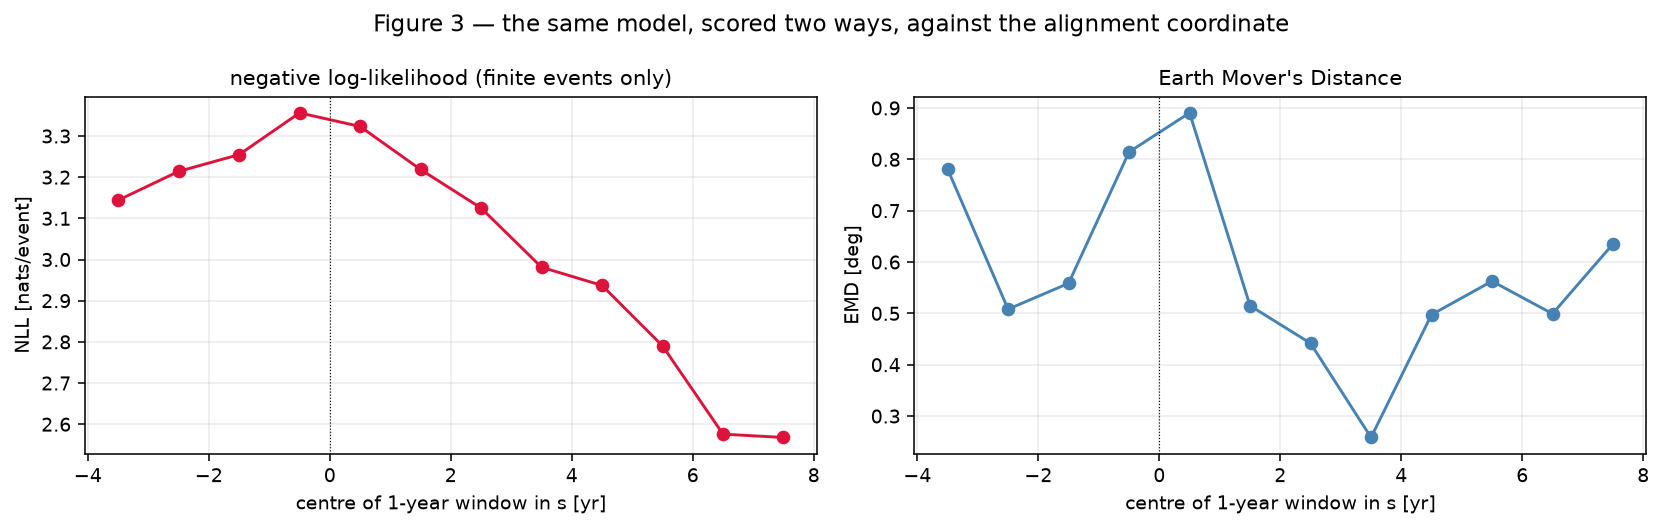

In [25]:
# Given: both metrics, window by window.
WINDOW_EDGES = np.arange(-5.0, 10.0, 1.0)
emd_rng = np.random.default_rng(SEED + 1)

window_rows = []
for lo, hi in zip(WINDOW_EDGES[:-1], WINDOW_EDGES[1:]):
    emd, n_in = emd_in_window(shape_span, lo, hi, emd_rng)
    in_window = (s_of_event >= lo) & (s_of_event < hi)
    finite_here = in_window & scored
    window_rows.append(dict(
        s_centre=0.5 * (lo + hi), n=n_in, emd=emd,
        nll=float(nll_of_event[finite_here].mean()) if finite_here.any() else np.nan,
        frac_impossible=float((in_window & ~scored).sum() / max(in_window.sum(), 1)),
    ))
windows = pd.DataFrame(window_rows)
print(windows.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
good = windows["n"] >= MIN_EVENTS_PER_WINDOW
axes[0].plot(windows.loc[good, "s_centre"], windows.loc[good, "nll"], "o-", color="crimson")
axes[0].set_ylabel("NLL [nats/event]")
axes[0].set_title("negative log-likelihood (finite events only)")
axes[1].plot(windows.loc[good, "s_centre"], windows.loc[good, "emd"], "o-", color="steelblue")
axes[1].set_ylabel("EMD [deg]")
axes[1].set_title("Earth Mover's Distance")
for ax in axes:
    ax.set_xlabel("centre of 1-year window in s [yr]")
    ax.axvline(0.0, color="k", lw=0.6, ls=":")
fig.suptitle("Figure 3 — the same model, scored two ways, against the alignment coordinate")
plt.tight_layout()
plt.show()


### Dialogue for Section 2 — the two metrics

Nothing to write here. The block below steers the conversation you have with your tutor before you
implement Tasks 1 and 2.

```text
TUTOR DIRECTIVE — Section 2. Work this before the student implements Tasks 1 and 2.

Material: the student is about to score ButterflAI 1.0's latitude distribution two ways — a per-event
negative log-likelihood in nats per event, and an Earth Mover's Distance in degrees between the
observed and the modelled distribution of |latitude| inside a window of s. Figure 3 will plot both
against the window centre. Neither has been computed yet.

Hold the student to all four destinations below before they write any code. Reach them in whatever
order the conversation takes, and reach them through the student's own reformulation rather than
through your exposition.

1. What each metric reacts to. Section 1.5 already shows real sunspot groups sitting inside the region
   where the 1.0 model's gate is shut and its density is exactly zero. Get the student to predict what
   those groups do to each of the two scores, and to say which of the two can be infinite, and why.
2. The two metrics can be pushed in opposite directions. Ask the student to describe a change to a
   model that improves one score while worsening the other, and then a change that does the reverse.
   Descriptions, not code. Do not supply either construction.
3. Reporting. One of the two is unbounded; the other depends on a random draw from the model. If the
   student states a preference for one as a competition's headline number, do not accept it until they
   have also said what must be reported alongside it — including the convention used for the events the
   model calls impossible.
4. What neither metric sees. Both are averages over the events that happened, and both would be
   unchanged if the groups had emerged in a different order, or if half of them had never emerged at
   all. Make the student state the question about the Sun that is invisible to both, in their own
   words, before you confirm or correct it.

If the student has not yet used `negative log-likelihood` or `Earth Mover's Distance` in a sentence of
their own, prefer one of those two when you choose the anchor at the next closure.
```

From Week 2 onward the likelihood is computed on event *times and positions* together, and reported in
nats per hemicycle-year rather than nats per event. That change of units is not cosmetic: a score per event
cannot reward a model for getting the number of events right, because it divides that number out. A score
per unit time can.

---
## 3 · The emergence table

To treat the catalog as a point process we have to commit to one **event time** per group. The choice
changes what we are modeling.

1.0 used the maximum-area observation. That is the right choice for asking *where* a group is, because the
group is then largest and best measured. It is the wrong choice for asking *when it appeared*: a group
typically reaches peak area several days after it is first seen, and how long it takes depends on how big
it grows. Using peak area as the event time would make large groups systematically late, which is exactly
the kind of correlation between an event's time and its properties that a point-process model would then
try to explain as physics.

So from here on, an event is a group's *first observation*: the first day it appears in the catalog at
all. That is the moment the Sun handed us the group — not the moment of emergence itself, which nobody
recorded, and the gap between the two is the first caveat below.

Two caveats, both from `data/README.md`, both important enough to repeat whenever a result is quoted:

- *First observation is not emergence.* Across the analysis set, the median distance from central meridian
  at first observation is about 65°, and fewer than half of groups are first seen within 60° of disk
  center. Some groups emerge on the far side and rotate into view; others emerge near the limb where they
  are hard to see. The recorded time therefore lags true emergence by up to several days, and lags it
  *unevenly*. This matters for anything at timescales of days to a solar rotation — which is precisely the
  regime we are about to probe — and matters much less for the cycle-scale envelope.
- *There is no exposure record.* The catalog has a row for nearly every calendar day, so the presence of a
  row does not mean the Sun was observed. An exposure record rebuilt from the original observing logs gives
  a mean observed fraction of about 0.99 for cycles 12–23, so we treat the record as fully observed. That
  is an assumption, it is worth roughly 1% in any rate we compute, and it does not transfer to other
  catalogs.

In [ ]:
# raise NotImplementedError("Task 3: Build the emergence table from first observations")
# Reference workflow:
#   1. Sort the observations by time, then keep the first row of each `uniqueID` — that row carries the
#      event's time, latitude and longitude.
#   2. Separately, take each group's maximum `correctedArea` (the size it eventually reached, which we need
#      for the selection cut) and its first non-null `CYCLE` label.
#   3. Assemble those into one frame, drop groups that carry no cycle label at all, and add the hemisphere
#      from the sign of the event's own latitude plus a column for |latitude|.

In [29]:
def build_emergence_table(obs):
    ordered=obs.sort_values('t',kind='stable')
    first=ordered.drop_duplicates('uniqueID').copy()
    peak=obs.groupby('uniqueID').correctedArea.max()
    labels=ordered.dropna(subset=['CYCLE']).drop_duplicates('uniqueID').set_index('uniqueID').CYCLE
    first['peak_area']=first.uniqueID.map(peak)
    first['cycle']=first.uniqueID.map(labels)
    first=first.dropna(subset=['cycle','latitude']).copy()
    first['cycle']=first.cycle.astype(int)
    first['hemisphere']=np.where(first.latitude>=0,'north','south')
    first['abs_latitude']=first.latitude.abs()
    return first.reset_index(drop=True)

### The analysis set

Two cuts define the set of events this program models, and both are choices rather than facts.

*Cycles 12 to 23.* Cycle 11 and earlier are in the catalog, but the area measurements before the
Royal Greenwich series are less homogeneous, and 1.0 fitted its reference epochs only from cycle 12 on.
Cycles 24 and 25 are incomplete in this file. That leaves 24 hemispheric cycles, which is also our entire
sample size for validation — a point that will constrain everything in Week 4.

*Peak corrected area above 30 MSH.* The smallest objects in the catalog are pores and marginal detections,
and whether one was recorded depends strongly on the observatory and the era. Including them would make
the emergence rate a measure of catalog sensitivity as much as of solar activity. The cut is applied on
each group's maximum area over its whole lifetime, not on its area at first observation, so a group is
kept or dropped on what it became rather than on how it happened to look on its first day.

Both are recorded as provisional decisions for the program, which means a later week may revisit them —
and if it does, every number downstream has to be recomputed rather than patched.

In [ ]:
# raise NotImplementedError("Task 4: Apply the analysis set and attach the alignment coordinate")
# Reference workflow:
#   1. Build a boolean mask for the analysis set: cycle between `CYCLE_MIN` and `CYCLE_MAX` inclusive, and
#      peak area strictly greater than `PEAK_AREA_MIN`. Copy the selected rows.
#   2. Look up each row's `t0` in `T0` using its (cycle, hemisphere), and subtract it from `t` to get `s`.
#   3. Add a short label per hemispheric cycle, e.g. "19N", so later code can group on one column.
#   4. Return the table sorted by hemicycle and then by `s`, with a fresh index.

In [32]:
def apply_analysis_set(table):
    table=table[table.cycle.between(CYCLE_MIN,CYCLE_MAX)&(table.peak_area>PEAK_AREA_MIN)].copy()
    table['t0']=[T0[(c,h)] for c,h in zip(table.cycle,table.hemisphere)]
    table['s']=table.t-table.t0
    table['hemicycle']=[str(c)+h[0].upper() for c,h in zip(table.cycle,table.hemisphere)]
    return table.sort_values(['hemicycle','s'],kind='stable').reset_index(drop=True)

A note on the hemisphere. We assign it from the sign of the event's own latitude, at first observation, so
that each event's latitude and hemisphere always agree. Section 1 kept 1.0's convention instead, taking the
hemisphere from the latitude at peak area, because the cycle amplitudes had to reproduce 1.0's. Fifty
groups near the equator are labelled differently by the two rules. It changes nothing here, and it is the
sort of detail that silently changes a number three weeks from now if it is not written down.

In [35]:
# Given: build, verify, cache. Rebuilding costs about a second, so we always rebuild and only the write is
# skipped — a stale cache can never hide a broken task. When fits get expensive, the skip moves to the fit.
EMERGENCE_CSV = DERIVED / "emergences.csv"
FORCE_REBUILD = False

emergences = apply_analysis_set(build_emergence_table(obs))

if EMERGENCE_CSV.exists() and not FORCE_REBUILD:
    print(f"cache already present, leaving it alone : {EMERGENCE_CSV}")
else:
    emergences.to_csv(EMERGENCE_CSV, index=False)
    print(f"wrote {EMERGENCE_CSV}")

n_events = len(emergences)
hemicycle_spans = emergences.groupby("hemicycle")["s"].agg(["min", "max", "count"])
hemicycle_years = float((hemicycle_spans["max"] - hemicycle_spans["min"]).sum())

print(f"\nemergence events in the analysis set : {n_events:,}")
print(f"hemispheric cycles                   : {emergences['hemicycle'].nunique()}")
print(f"events per hemicycle                 : {hemicycle_spans['count'].min()} to "
      f"{hemicycle_spans['count'].max()}  (median {int(hemicycle_spans['count'].median())})")
print(f"observed hemicycle-years in total    : {hemicycle_years:.1f}")
print(f"mean emergence rate                  : {n_events / hemicycle_years:.1f} events per hemicycle-year")
print(f"s spans                              : {emergences['s'].min():+.2f} to "
      f"{emergences['s'].max():+.2f} yr")

print("\nevents per hemispheric cycle:")
print(emergences.pivot_table(index="cycle", columns="hemisphere", values="uniqueID",
                             aggfunc="count").to_string())

assert n_events == 22_122, f"expected 22,122 events in the analysis set, got {n_events:,}"
print("\nfirst five events:")
print(emergences[["uniqueID", "t", "s", "latitude", "hemisphere", "cycle", "peak_area"]]
      .head().to_string(index=False))

wrote data/derived/emergences.csv

emergence events in the analysis set : 22,122
hemispheric cycles                   : 24
events per hemicycle                 : 522 to 1590  (median 955)
observed hemicycle-years in total    : 253.6
mean emergence rate                  : 87.2 events per hemicycle-year
s spans                              : -4.78 to +8.74 yr

events per hemispheric cycle:
hemisphere  north  south
cycle                   
12            522    667
13            716    850
14            613    640
15            794    697
16            789    675
17           1001   1020
18           1138   1133
19           1590   1121
20           1208    996
21           1025   1049
22            860    983
23            928   1107

first five events:
uniqueID           t         s  latitude hemisphere  cycle  peak_area
SP_10824 1878.557534 -4.041779     13.62      north     12      125.0
SP_10825 1878.620548 -3.978765     34.50      north     12       41.0
SP_10829 1878.839726 -3.75958

---
## 4 · The counting process

We now have 24 realizations of a point process. There are two equivalent ways to look at one of them.

The **counting process** N(s) is the number of events that have happened by time `s`. It is a staircase:
flat between events, stepping up by one at each event. All the information is in where the steps are, and
N(s) makes the *accumulated* behaviour easy to see — the slope of the staircase at any point is the local
emergence rate.

The **inter-arrival time** is the gap between consecutive events. Same data, differenced instead of
summed, and it makes the *local* behaviour easy to see.

Neither view adds information. They make different things obvious, which is the only reason to have both.

In [ ]:
# raise NotImplementedError("Task 5: Cumulative count N(s) for one hemicycle")
# Reference workflow:
#   1. Sort the event times. A point process has no inherent order, so nothing may assume the table is
#      already sorted.
#   2. The count after the k-th event is k, so return the sorted times alongside 1, 2, ... up to the number
#      of events.

In [37]:
def counting_process(event_s):
    event_s=np.sort(np.asarray(event_s,dtype=float))
    return event_s,np.arange(1,len(event_s)+1)

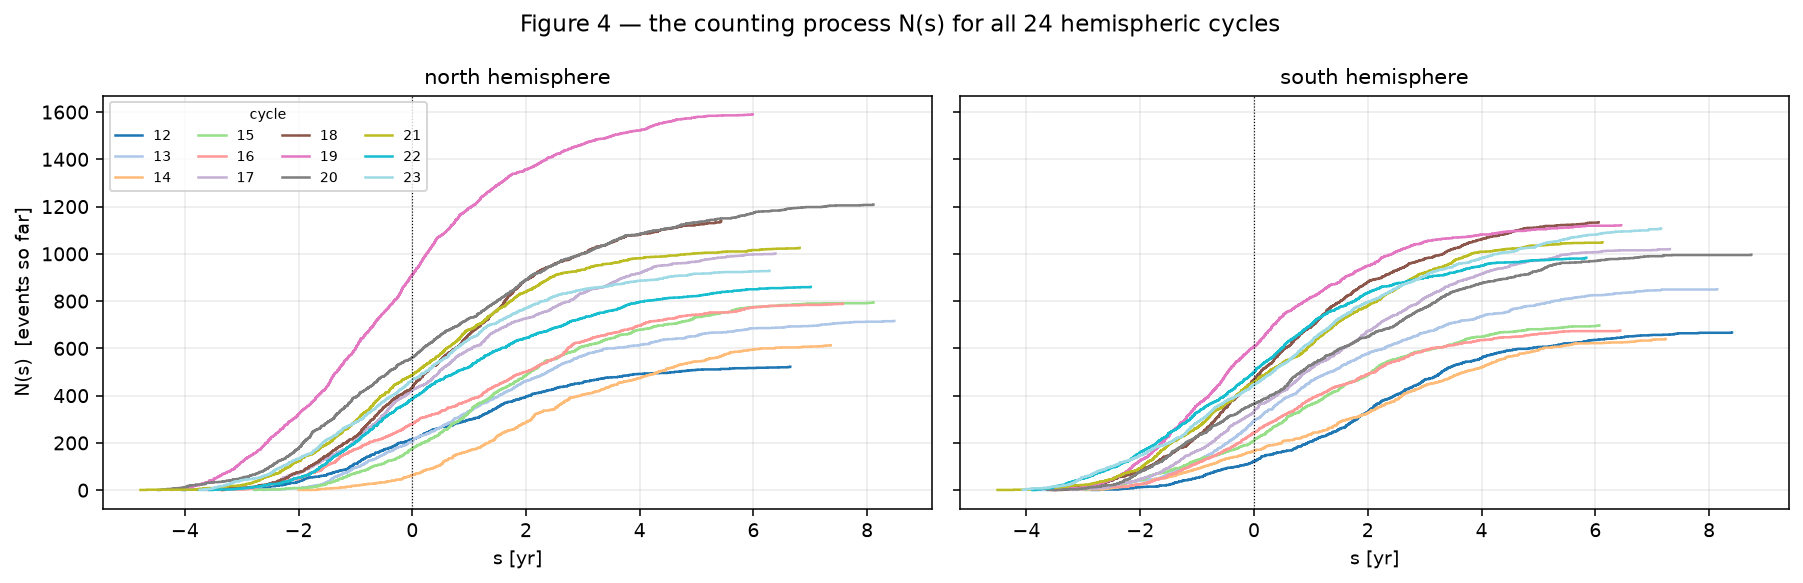

In [12]:
# Given: every hemispheric cycle's staircase, one panel per hemisphere.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
cyc_colors = plt.get_cmap("tab20", CYCLE_MAX - CYCLE_MIN + 1)

for ax, hemi in zip(axes, HEMISPHERES):
    for i, cyc in enumerate(CYCLES):
        label = f"{cyc}{hemi[0].upper()}"
        sel = emergences.loc[emergences["hemicycle"] == label, "s"]
        s_sorted, counts = counting_process(sel)
        ax.step(s_sorted, counts, where="post", lw=1.3, color=cyc_colors(i), label=f"{cyc}")
    ax.axvline(0.0, color="k", lw=0.6, ls=":")
    ax.set_xlabel("s [yr]")
    ax.set_title(f"{hemi} hemisphere")
axes[0].set_ylabel("N(s)  [events so far]")
axes[0].legend(ncol=4, fontsize=7, title="cycle", title_fontsize=7, loc="upper left")
fig.suptitle("Figure 4 — the counting process N(s) for all 24 hemispheric cycles")
plt.tight_layout()
plt.show()

Read the slopes. Every staircase is shallow at negative `s`, steepens to a maximum somewhere around
`s` = 0 to 2, then flattens out over the following five years or so. The total height varies by a factor
of three between the weakest and strongest wings, and the *shape* varies much less than the height. That
is the emergence rate we are going to model.

The curves do not all start or end at the same place, because each hemispheric cycle has its own observed
span in `s`. That is a nuisance we have to handle deliberately rather than ignore: any statistic computed
over "the whole wing" is computed over a different interval for each wing.

In [ ]:
# raise NotImplementedError("Task 6: Inter-arrival times for each hemicycle")
# Reference workflow:
#   1. Write a function that sorts one hemicycle's event times and returns the successive differences.
#   2. Apply it to each hemispheric cycle separately and concatenate the results. Never difference across a
#      hemicycle boundary — the gap between the last event of one wing and the first of another is not an
#      inter-arrival time of anything.

In [41]:
def interarrival_times(event_s):
    return np.diff(np.sort(np.asarray(event_s,dtype=float)))
gaps=np.concatenate([interarrival_times(g.s.to_numpy()) for _,g in emergences.groupby('hemicycle')])

inter-arrival times        : 22,098
median                     : 2.01 days
mean                       : 4.19 days
exactly zero               : 3,631 (16.4%)
quantiles [1,10,50,90,99]% : [ 0.    0.    2.01  9.   32.85] days


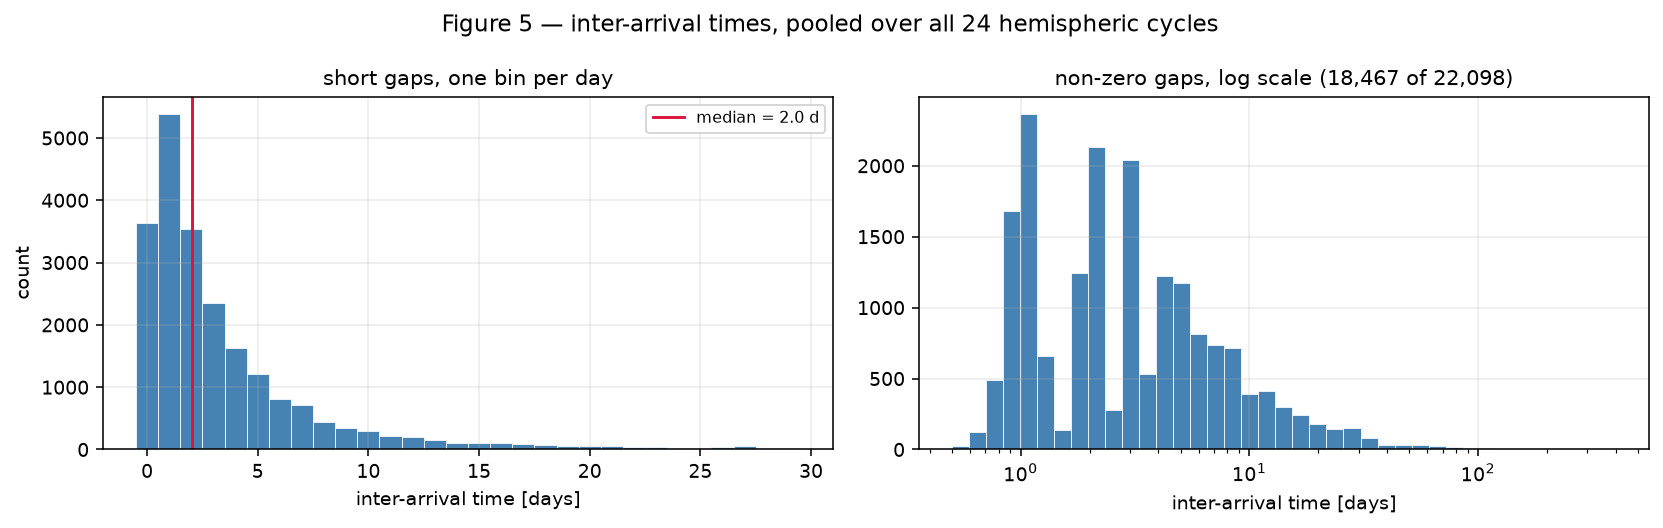

In [43]:
# Given: the distribution of those gaps.
gaps_days = gaps * 365.25
n_tied = int((gaps_days == 0).sum())

print(f"inter-arrival times        : {len(gaps):,}")
print(f"median                     : {np.median(gaps_days):.2f} days")
print(f"mean                       : {gaps_days.mean():.2f} days")
print(f"exactly zero               : {n_tied:,} ({n_tied / len(gaps) * 100:.1f}%)")
print(f"quantiles [1,10,50,90,99]% : "
      f"{np.round(np.quantile(gaps_days, [0.01, 0.1, 0.5, 0.9, 0.99]), 2)} days")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(gaps_days, bins=np.arange(-0.5, 30.5, 1.0), color="steelblue", edgecolor="white", lw=0.4)
axes[0].axvline(np.median(gaps_days), color="crimson", lw=1.5,
                label=f"median = {np.median(gaps_days):.1f} d")
axes[0].set_xlabel("inter-arrival time [days]")
axes[0].set_ylabel("count")
axes[0].set_title("short gaps, one bin per day")
axes[0].legend(fontsize=8)

nonzero = gaps_days[gaps_days > 0]
axes[1].hist(nonzero, bins=np.logspace(np.log10(0.5), np.log10(400), 40),
             color="steelblue", edgecolor="white", lw=0.4)
axes[1].set_xscale("log")
axes[1].set_xlabel("inter-arrival time [days]")
axes[1].set_title(f"non-zero gaps, log scale ({len(nonzero):,} of {len(gaps):,})")
fig.suptitle("Figure 5 — inter-arrival times, pooled over all 24 hemispheric cycles")
plt.tight_layout()
plt.show()

Two features of the left panel are properties of the catalog, not of the Sun, and both will matter later.

The gaps are quantized to whole days, because the catalog records one observation per observatory per day.
There is no information about sub-day gaps, so one day is the finest timescale at which any statistic here
can mean anything.

And about a sixth of the gaps are exactly zero. Those are groups first seen in the *same* observation as
another group — they share a timestamp exactly, so their gap is zero rather than small. Using the recorded
hour and minute does not help, because the two groups genuinely were recorded at the same instant. For the
window counts in Section 5 this is harmless, since we never use a window narrower than a day. For the
time-rescaling test in Week 2 it is not harmless, and we will have to deal with it there.

---
## 5 · The Fano factor

Now the week's question. A **Poisson process** is the point process with no memory: given its rate, what
happens in one interval tells you nothing about any other, a property called **independent increments**.
Equivalently it is **memoryless** — having waited ten days for the next event does not change the
distribution of how much longer you will wait.

It is the natural starting hypothesis, and it has a sharp, testable consequence. If you chop the timeline
into windows of width Δ and count the events in each, a Poisson process gives counts whose variance equals
their mean. So the **Fano factor**

```
F(Δ) = Var(counts in windows of width Δ) / Mean(counts in windows of width Δ)
```

equals 1 for a Poisson process, at every Δ. If F > 1 the counts are more variable than Poisson —
**overdispersion**, the signature of events arriving in clumps. If F < 1 they are more regular than
Poisson (underdispersion), which is what you get from something that suppresses its own successors.

Two things make F(Δ) a curve rather than a number, and both are the point of computing it:

- Clumping has a timescale. Events that cluster within a week inflate F at Δ of a few days and leave
  F at Δ of a year untouched.
- A *varying rate* also inflates F, at every Δ. If the Sun emerges 200 groups per year at one time and 20
  at another, then windows drawn from across a wing have wildly different means, and the variance of the
  pooled counts reflects that spread, not any clumping. Our rate varies by an order of magnitude within
  every wing, so we should expect large F before looking at the data, and it will tell us nothing on its
  own.

That second point is why most of this section is about what to compare against.

In [ ]:
# raise NotImplementedError("Task 7: Fano factor for one window width")
# Reference workflow:
#   1. Work out how many *complete* windows of width `delta` fit in [s_lo, s_hi], and lay down edges for
#      exactly those. Give up (NaN, zero windows) if fewer than two fit — a variance over one window is
#      meaningless. Do not let a partial window survive: a short last window holds fewer events for a
#      reason that has nothing to do with the process, and its count is not comparable with the others.
#   2. Count the events falling in each window with `np.histogram`.
#   3. Return the variance of those counts divided by their mean, together with how many windows there were.
#      Guard against a mean of zero. Use the *unbiased* variance (`ddof=1`, dividing by one less than the
#      number of windows): numpy's default divides by the number of windows, which underestimates the
#      variance by a factor (K-1)/K and would drag F below 1 at wide windows, where K is small.

In [46]:
def fano_factor(event_s,delta,s_lo,s_hi):
    K=int(np.floor((s_hi-s_lo)/delta))
    if K<2:return np.nan,0
    edges=s_lo+np.arange(K+1)*delta
    # Histogram-equivalent count calculation on sorted events.
    events=np.sort(np.asarray(event_s,dtype=float))
    cuts=np.searchsorted(events,edges,side='left')
    cuts[-1]=np.searchsorted(events,edges[-1],side='right')
    counts=np.diff(cuts)
    mean=float(counts.mean())
    if mean==0:return np.nan,K
    return float(counts.var(ddof=1)/mean),K

In [48]:
# Given: pool one F(Δ) curve over many realizations, weighting each by its number of windows, so a wing
# that contributes 4000 one-day windows counts more than one contributing 5 two-year windows.
DELTAS_DAYS = np.array([1, 2, 3, 5, 7, 10, 14, 20, 27, 40, 60, 90, 135, 200, 300, 450, 730])
DELTAS = DELTAS_DAYS * ONE_DAY     # 27 days is in the list on purpose: the solar rotation period


def fano_curve(units, deltas=DELTAS):
    """`units` is an iterable of (event_s, s_lo, s_hi). Returns F at each delta."""
    curve = np.full(len(deltas), np.nan)
    for i, delta in enumerate(deltas):
        total, weight = 0.0, 0.0
        for event_s, s_lo, s_hi in units:
            f, n_windows = fano_factor(event_s, delta, s_lo, s_hi)
            if np.isfinite(f):
                total += f * n_windows
                weight += n_windows
        if weight:
            curve[i] = total / weight
    return curve


def hemicycle_units(table, hemisphere=None):
    """Split a table into (event_s, s_lo, s_hi) per hemispheric cycle, over its own observed span."""
    sel = table if hemisphere is None else table[table["hemisphere"] == hemisphere]
    units = []
    for _, group in sel.groupby("hemicycle"):
        s_values = group["s"].to_numpy()
        units.append((s_values, s_values.min(), s_values.max()))
    return units


DATA_UNITS = {hemi: hemicycle_units(emergences, hemi) for hemi in HEMISPHERES}
print(f"north: {len(DATA_UNITS['north'])} hemicycles, south: {len(DATA_UNITS['south'])} hemicycles")

north: 12 hemicycles, south: 12 hemicycles


### 5.1 · Check the ruler before measuring with it

Before computing F(Δ) on the Sun, compute it on a process whose answer we already know. A homogeneous
Poisson process — constant rate, no memory — must give F ≈ 1 at every Δ, up to the sampling error of
having only a finite number of windows. If our estimator does not reproduce that, nothing it says about
the data is worth reading.

This is not a formality. Two details of Task 7 are wrong in the obvious implementation, and both only
show up at wide windows, where the data's most interesting behaviour lives. A trailing window narrower
than Δ holds fewer events for a bookkeeping reason rather than a physical one, and numpy's default
variance divides by the number of windows rather than one less, which biases F low by (K−1)/K. With
five windows that is a 20% error — larger than any departure we are going to find in the data.

In [ ]:
# raise NotImplementedError("Task 8: Simulate a homogeneous Poisson process and check F(Δ) is 1")
# Reference workflow:
#   1. The number of events on an interval of a Poisson process is itself Poisson distributed, with mean
#      rate times duration. Draw it.
#   2. Given the number of events, their positions are independent and uniform on the interval. Draw them
#      and sort.

In [50]:
def simulate_homogeneous_poisson(rate,duration,rng):
    n=rng.poisson(rate*duration)
    return np.sort(rng.uniform(0,duration,n))

simulated rate 87.2 events/yr over 10.57 yr, 24 units x 1000 realizations
   delta =    1 d   F = 1.000   95% band [0.991, 1.010]
   delta =    2 d   F = 1.000   95% band [0.988, 1.015]
   delta =    3 d   F = 1.000   95% band [0.984, 1.017]
   delta =    5 d   F = 1.000   95% band [0.979, 1.022]
   delta =    7 d   F = 1.000   95% band [0.976, 1.025]
   delta =   10 d   F = 1.000   95% band [0.970, 1.030]
   delta =   14 d   F = 1.000   95% band [0.964, 1.036]
   delta =   20 d   F = 0.999   95% band [0.960, 1.040]
   delta =   27 d   F = 1.000   95% band [0.953, 1.046]
   delta =   40 d   F = 0.999   95% band [0.940, 1.055]
   delta =   60 d   F = 0.999   95% band [0.926, 1.071]
   delta =   90 d   F = 1.000   95% band [0.917, 1.093]
   delta =  135 d   F = 1.000   95% band [0.895, 1.114]
   delta =  200 d   F = 0.999   95% band [0.871, 1.153]
   delta =  300 d   F = 1.000   95% band [0.848, 1.189]
   delta =  450 d   F = 1.000   95% band [0.795, 1.222]
   delta =  730 d   F = 1.002 

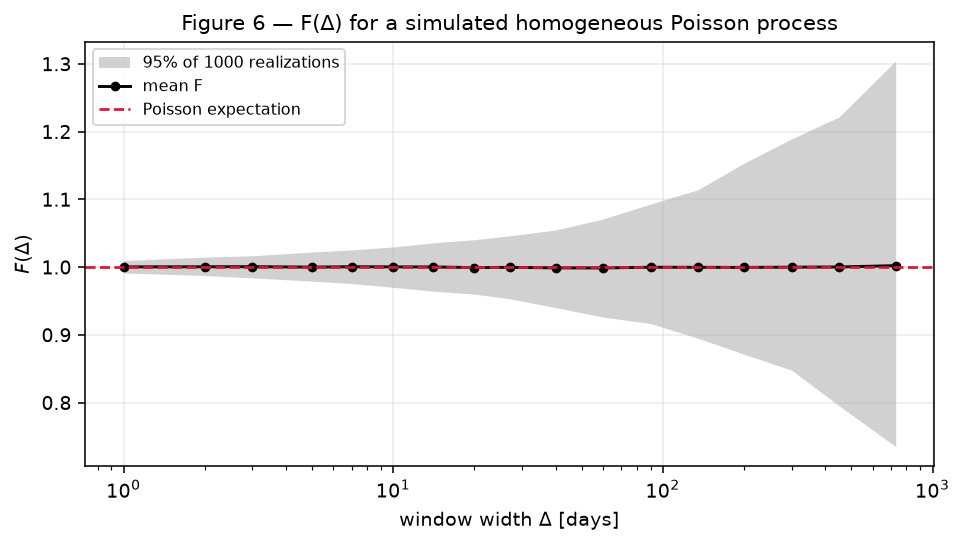

In [17]:
# Given: 24 simulated units matched to the data's rate and span, 1,000 times over.
N_REALIZATIONS = 1000
SIM_RATE = n_events / hemicycle_years                  # events per year
SIM_DURATION = float((hemicycle_spans["max"] - hemicycle_spans["min"]).mean())
poisson_rng = np.random.default_rng(SEED + 2)

poisson_curves = np.array([
    fano_curve([(simulate_homogeneous_poisson(SIM_RATE, SIM_DURATION, poisson_rng),
                 0.0, SIM_DURATION) for _ in range(24)])
    for _ in range(N_REALIZATIONS)
])
poisson_lo, poisson_hi = np.percentile(poisson_curves, [2.5, 97.5], axis=0)

print(f"simulated rate {SIM_RATE:.1f} events/yr over {SIM_DURATION:.2f} yr, "
      f"24 units x {N_REALIZATIONS} realizations")
for i, delta_d in enumerate(DELTAS_DAYS):
    print(f"   delta = {delta_d:4d} d   F = {poisson_curves[:, i].mean():5.3f}   "
          f"95% band [{poisson_lo[i]:5.3f}, {poisson_hi[i]:5.3f}]")

outside = [int(d) for i, d in enumerate(DELTAS_DAYS)
           if not (poisson_lo[i] <= 1.0 <= poisson_hi[i])]
assert not outside, f"F=1 fell outside the simulated band at delta = {outside} days"
print("\nF = 1 lies inside the sampling band at every window width. The estimator is sound.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(DELTAS_DAYS, poisson_lo, poisson_hi, color="0.7", alpha=0.6, lw=0,
                label=f"95% of {N_REALIZATIONS} realizations")
ax.plot(DELTAS_DAYS, poisson_curves.mean(axis=0), "o-", color="k", ms=4, label="mean F")
ax.axhline(1.0, color="crimson", lw=1.4, ls="--", label="Poisson expectation")
ax.set_xscale("log")
ax.set_xlabel(r"window width $\Delta$ [days]")
ax.set_ylabel(r"$F(\Delta)$")
ax.set_title("Figure 6 — F(Δ) for a simulated homogeneous Poisson process")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 5.2 · F(Δ) on the Sun

Same estimator, real events, one curve per hemisphere.

In [17]:
# Given: the data curves.
fano_data = {hemi: fano_curve(DATA_UNITS[hemi]) for hemi in HEMISPHERES}

print(f"{'delta [d]':>10} {'F north':>9} {'F south':>9}")
for i, delta_d in enumerate(DELTAS_DAYS):
    print(f"{delta_d:10d} {fano_data['north'][i]:9.2f} {fano_data['south'][i]:9.2f}")

 delta [d]   F north   F south
         1      1.17      1.16
         2      1.26      1.24
         3      1.38      1.35
         5      1.61      1.54
         7      1.86      1.77
        10      2.19      2.05
        14      2.61      2.45
        20      3.25      3.05
        27      4.03      3.79
        40      5.63      5.28
        60      7.89      7.46
        90     11.38     10.68
       135     16.43     15.40
       200     23.40     22.40
       300     34.75     32.57
       450     50.56     47.76
       730     76.63     67.72


F runs from about 1.17 at one day to roughly 70 at two years, and the two hemispheres agree closely.
Taken at face value this is overdispersion by a factor of seventy, and it would be a dramatic result —
except that we predicted something like it before looking, purely from the fact that the emergence rate
varies through a wing. The number is real; the interpretation "the Sun clumps its emergences
seventy-fold" is not available from it.

### 5.3 · A null model with the right rate

To make F(Δ) say anything, we need to know what F(Δ) would have been if the Sun were Poisson *with the
same slowly varying rate*. That comparison is a **null model**: a process built to share with the data
everything we are not testing, and to lack exactly the thing we are testing for.

We build it per hemispheric cycle:

1. Bin the wing's events into daily counts.
2. Smooth those counts over a window of `smooth_days` to get a slowly varying rate.
3. Draw a fresh daily count from a Poisson distribution with that rate.
4. Place the drawn events uniformly within their day.

The result has the data's rate envelope and, by construction, no memory at all. Whatever F(Δ) the data has
*in excess of* this null is not explained by the rate envelope.

The smoothing width is the one knob, and it decides what counts as "the rate" rather than "a fluctuation".
We will turn it, because the answer depends on it.

In [ ]:
# raise NotImplementedError("Task 9: Build a Poisson null with the same slowly varying rate")
# Reference workflow:
#   1. Histogram the wing's events into one-day bins spanning [s_lo, s_hi].
#   2. Smooth the daily counts with a boxcar of width `smooth_days`. Divide by the boxcar applied to an array
#      of ones, so days near the edges are not dragged toward zero by the window running off the end.
#   3. Draw a new count for every day from a Poisson with the smoothed rate as its mean.
#   4. Scatter each day's drawn events uniformly inside that day, and return them sorted.

In [56]:
def simulate_rate_matched_null(event_s,s_lo,s_hi,smooth_days,rng):
    edges=s_lo+np.arange(int(np.ceil((s_hi-s_lo)/ONE_DAY))+1)*ONE_DAY
    counts,_=np.histogram(event_s,bins=edges)
    kernel=np.ones(int(smooth_days),dtype=float)
    rate=np.convolve(counts,kernel,mode='same')/np.convolve(np.ones_like(counts,dtype=float),kernel,mode='same')
    draw=rng.poisson(rate)
    day_indices=np.repeat(np.arange(len(draw)),draw)
    events=edges[day_indices]+rng.random(len(day_indices))*ONE_DAY
    return np.sort(events[events<=s_hi])

In [17]:
# Given: two nulls, differing only in the smoothing width, 1,000 realizations each.
NULL_WINDOWS = {"1-year null": 365, "3-month null": 91}
null_curves = {}

for offset, (name, smooth_days) in enumerate(NULL_WINDOWS.items()):
    rng = np.random.default_rng(SEED + 3 + offset)
    for hemi in HEMISPHERES:
        null_curves[(name, hemi)] = np.array([
            fano_curve([(simulate_rate_matched_null(s_values, s_lo, s_hi, smooth_days, rng),
                         s_lo, s_hi)
                        for s_values, s_lo, s_hi in DATA_UNITS[hemi]])
            for _ in range(N_REALIZATIONS)
        ])

for hemi in HEMISPHERES:
    print(f"\n{hemi} hemisphere")
    print(f"{'delta [d]':>10} {'F data':>8}" + "".join(f"{n:>14}" for n in NULL_WINDOWS)
          + "   ratio vs each null")
    for i, delta_d in enumerate(DELTAS_DAYS):
        row = f"{delta_d:10d} {fano_data[hemi][i]:8.2f}"
        ratios = []
        for name in NULL_WINDOWS:
            mean_null = null_curves[(name, hemi)][:, i].mean()
            row += f"{mean_null:14.2f}"
            ratios.append(f"{fano_data[hemi][i] / mean_null:5.3f}")
        print(row + "   " + "  ".join(ratios))


north hemisphere
 delta [d]   F data   1-year null  3-month null   ratio vs each null
         1     1.17          1.11          1.12   1.058  1.044
         2     1.26          1.22          1.25   1.035  1.009
         3     1.38          1.33          1.37   1.038  1.002
         5     1.61          1.55          1.62   1.043  0.992
         7     1.86          1.76          1.87   1.055  0.993
        10     2.19          2.09          2.25   1.045  0.972
        14     2.61          2.53          2.75   1.033  0.952
        20     3.25          3.18          3.49   1.022  0.932
        27     4.03          3.95          4.36   1.021  0.925
        40     5.63          5.36          5.95   1.049  0.945
        60     7.89          7.56          8.39   1.043  0.939
        90    11.38         10.82         11.93   1.052  0.954
       135    16.43         15.73         17.15   1.045  0.958
       200    23.40         22.74         24.18   1.029  0.968
       300    34.75         33.

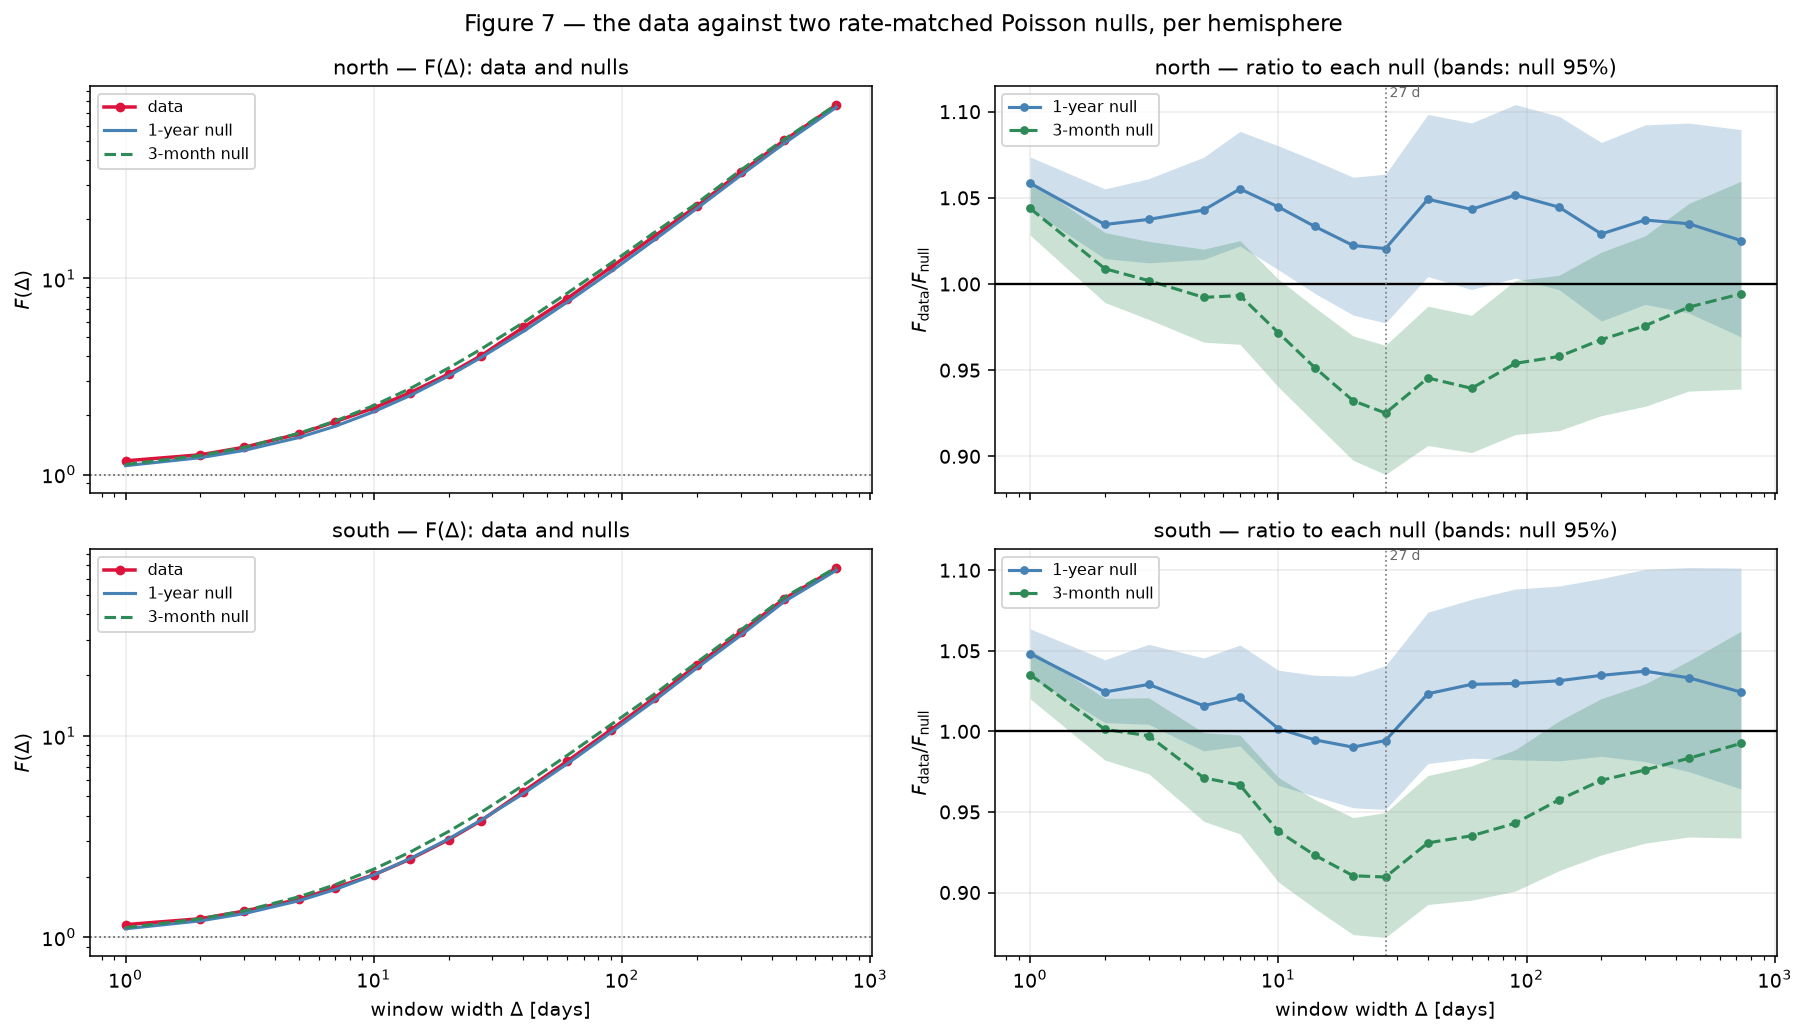

In [59]:
# Given: Figure 7.
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharex=True)
null_styles = {"1-year null": ("steelblue", "-"), "3-month null": ("seagreen", "--")}

for row, hemi in enumerate(HEMISPHERES):
    ax_f, ax_r = axes[row, 0], axes[row, 1]

    ax_f.plot(DELTAS_DAYS, fano_data[hemi], "o-", color="crimson", ms=4, lw=1.8, label="data")
    for name, (color, ls) in null_styles.items():
        band = null_curves[(name, hemi)]
        ax_f.plot(DELTAS_DAYS, band.mean(axis=0), ls=ls, color=color, lw=1.6, label=name)
    ax_f.axhline(1.0, color="0.4", lw=0.9, ls=":")
    ax_f.set_xscale("log")
    ax_f.set_yscale("log")
    ax_f.set_ylabel(r"$F(\Delta)$")
    ax_f.set_title(f"{hemi} — F(Δ): data and nulls")
    ax_f.legend(fontsize=8, loc="upper left")

    for name, (color, ls) in null_styles.items():
        band = null_curves[(name, hemi)]
        lo, hi = np.percentile(band, [2.5, 97.5], axis=0)
        ax_r.fill_between(DELTAS_DAYS, fano_data[hemi] / hi, fano_data[hemi] / lo,
                          color=color, alpha=0.25, lw=0)
        ax_r.plot(DELTAS_DAYS, fano_data[hemi] / band.mean(axis=0), ls=ls, marker="o", ms=3.5,
                  color=color, lw=1.6, label=name)
    ax_r.axhline(1.0, color="k", lw=1.2)
    ax_r.axvline(27, color="0.5", lw=0.9, ls=":")
    ax_r.text(27, ax_r.get_ylim()[1], " 27 d ", fontsize=7, color="0.4", ha="left", va="top")
    ax_r.set_xscale("log")
    ax_r.set_ylabel(r"$F_{\rm data} / F_{\rm null}$")
    ax_r.set_title(f"{hemi} — ratio to each null (bands: null 95%)")
    ax_r.legend(fontsize=8)

for ax in axes[1, :]:
    ax.set_xlabel(r"window width $\Delta$ [days]")
fig.suptitle("Figure 7 — the data against two rate-matched Poisson nulls, per hemisphere")
plt.tight_layout()
plt.show()


### Dialogue for Section 6 — dispersion, and what the null model decides

Again nothing to write. Have this conversation before you run Section 5, so that you have committed to
an expectation before you see the answer.

```text
TUTOR DIRECTIVE — Section 6. Work this before the student runs Section 5.

Material: the student is about to compute F(delta) = Var/Mean over window widths from one day to two
years, for the real emergences and for two Poisson null models. Both nulls are built to share the
data's rate envelope and to have no memory; they differ in exactly one knob, the width of the boxcar
used to estimate that rate from the data (365 days and 91 days).

Work this predictively. Get the student to commit to an expectation while no number exists yet, then
hold them to the destinations below. Do not state any of the outcomes yourself.

1. Start here: what should F(delta) be for a memoryless process, and what will an emergence rate that
   varies by an order of magnitude across a hemispheric cycle do to it? Section 5's text asserts both;
   require the reasoning rather than the assertion, and get a prediction for the shape of the curve.
2. The two nulls will disagree with the data in opposite directions over most of the range. Ask the
   student what it would mean for a reported result if the sign of a departure depended on the
   analyst's choice of smoothing width.
3. There is one narrow band of delta where the data departs from both nulls in the same direction. Ask
   the student to predict which band, and to connect it to something Figure 5 shows directly about
   inter-arrival times. Do not name the band.
4. Ask why a null whose rate is estimated from the data over a short window should end up more variable
   than the data rather than smoother. Make them reason about what the smoothed daily counts contain
   besides the rate, and what step 3 of the recipe then does with it. This is the hardest destination;
   bridge towards it rather than supplying it.
5. Make the student state what the 1-year null assumes about the Sun that is not the thing being tested.
6. The 27-day solar rotation period. Section 3 told them where groups are first seen relative to disk
   centre. Ask what a group emerging on the far side does to a count in a 27-day window, and whether a
   null result at 27 days would be informative either way.
7. Close on the logic. Would F(delta) = 1 at every delta, against every null, establish that emergence
   is a Poisson process? Require a counterexample from the student, not an opinion.

`independent increments`, `null model` and `overdispersion` are the targets least likely to have been
deployed by this point; prefer them when you choose an anchor.
```

---
## Where this leaves us

The week's question was whether emergence is consistent with a memoryless process, and at what timescales.
The answer has two parts. At the one-day scale, no: the data is a few percent overdispersed against every
null we built, and that excess is anchored in something we can point at — groups arriving in the same
observation as other groups. Everywhere above a few days, F(Δ) cannot settle it. Not because the data is
poor, but because the statistic needs a rate model and we supplied one by smoothing, which buries the
answer under a choice of bandwidth.

That is the argument for what comes next. Instead of smoothing a rate and comparing variances, Week 2
*fits* a rate model by maximum likelihood on the event times, and then tests it with time-rescaling: if
the fitted rate is right, transforming the event times by the model's own cumulative intensity turns them
into a unit-rate Poisson process, whose inter-arrival times must be Exp(1). That test has no free
bandwidth. It is also the point at which the likelihood stops being per event and becomes per
hemicycle-year — which, as the Section 2 dialogue works out, is what it takes to score a model on how
many groups emerge rather than only on where.

Carried forward from this notebook: the emergence table in `data/derived/emergences.csv`, the alignment
coordinate `s`, the 24 hemispheric cycles as the unit of replication, and the habit of checking the ruler
before trusting the measurement.

---
## Before you push: save the conversation

Type `wrap up` in your tutor session. It runs a closure and prints a `HANDOFF` block. Copy that block
and save it as `vocal_handoff.md` in your week 01 submission folder, then push it together with your
completed notebook. The HANDOFF is part of this week's deliverable: the figures show what you computed,
and the HANDOFF is the record of the argument you built around them. It is also what you paste at the
start of next week's session, so that your tutor picks up where you left off instead of starting cold.

If a number came out differently from what you predicted in the session — and at least one of them will —
go back to the tutor, paste the numbers, and take a second HANDOFF. The latest one supersedes the earlier.